# 🚩 intraPSIC
## `model_personae.ipynb`

> `model_personae.ipynb`<br>
> Simone J. Skeen x Claude Code (08-14-2026)<br>
> WIP - NOT FOR DISTRIBUTION

Cell ID: df172a73

In [1]:
%%capture
# === INSTALL DEPENDENCIES === #

%pip install -r ../requirements.txt

# Cell ID: f2e354df

In [2]:
# === STANDARD LIBRARY IMPORTS === #

import ast
import sys
import warnings
from pathlib import Path

# === THIRD-PARTY IMPORTS === #

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from stepmix.stepmix import StepMix

# IPython display configuration
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

# === PANDAS DISPLAY OPTIONS === #
# Show all columns and rows for debugging.

pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# === SUPPRESS WARNINGS === #
# Hide FutureWarning and UserWarning to keep output clean.

for category in (FutureWarning, UserWarning):
    warnings.simplefilter(action='ignore', category=category)

# === LOAD ENVIRONMENT VARIABLES === #
# The .env file should contain KNOW_DIR and optionally OLLAMA_HOST.

load_dotenv(Path('..') / '.env')

# === FILE PATHS === #

DATA_RAW = Path('..') / 'data' / 'raw'
DATA_PROC = Path('..') / 'data' / 'processed'

# Cell ID: 79eeeb98

In [3]:
# Import labeled dissertation data
d = pd.read_csv(DATA_RAW / 'd_inf_labeled_long.csv', index_col=0)

#d.info()
#d.head(5)

# Cell ID: e0b06eb9

In [4]:
#from condense import condense

#d = condense(d)

#d.info()
#d.head(5)

# Cell ID: e54fe1ff

In [5]:
from sanitize import sanitize

d = sanitize(d)

d.head(5)

# Cell ID: fc988b11

,asp,asp_prob,dep,dep_prob,val,val_prob,prg,prg_prob,tgd,tgd_prob,age,age_prob,race,race_prob,dbty,dbty_prob,gpe,sui,aut,adhd,bpd,ptsd
0,1,0.95,0,0.01,0,0.00,0,0.00,0,0.0,1,0.93,0,0.11,0,0.00,0,0,0,0,0,0
1,0,0.48,0,0.34,1,0.92,0,0.00,0,0.0,0,0.02,0,0.15,0,0.00,0,0,0,0,0,0
2,0,0.02,0,0.02,0,0.04,0,0.00,0,0.0,0,0.01,0,0.16,0,0.00,0,0,0,0,0,0
3,0,0.05,0,0.01,0,0.00,0,0.00,0,0.0,0,0.27,0,0.17,0,0.00,0,0,0,0,0,0
4,1,0.85,1,0.50,0,0.02,0,0.03,0,0.0,0,0.04,0,0.14,1,0.98,0,0,0,0,0,0


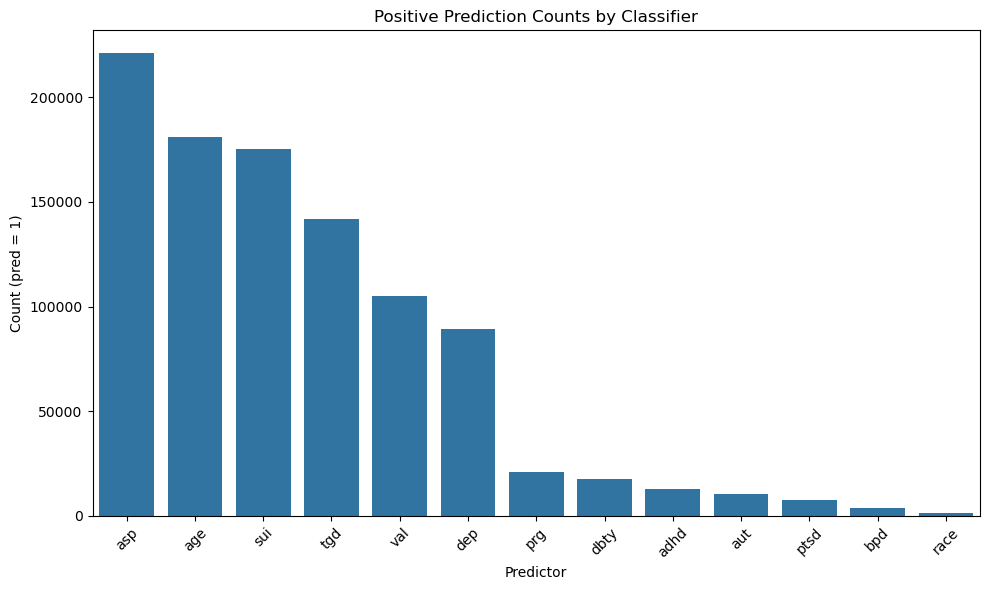

In [6]:
# Viz. counts

def plot_pred_counts(df, title='Positive Prediction Counts by Classifier'):
    pred_cols = ['asp', 'dep', 'val', 'prg', 'tgd', 'age', 'race', 'dbty',
                 'sui', 'aut', 'adhd', 'bpd', 'ptsd']
    
    counts = df[pred_cols].sum().sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=counts.index, y=counts.values, ax=ax)
    ax.set_xlabel('Predictor')
    ax.set_ylabel('Count (pred = 1)')
    ax.set_title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_pred_counts(d)

# Cell ID: 50284018

In [ ]:
%%script false --no-raise-error
#############################################################################

# Condense to prob ≥0.90

### NOTE 8/14: eliminates prominence of strain constructs; negates motivation; do not use

prob_cols = [col for col in d.columns if col.endswith('_prob')]
prefixes = [col.replace('_prob', '') for col in prob_cols]

for prefix in prefixes:
    pred_col = f'{prefix}'
    prob_col = f'{prefix}_prob'
    d.loc[d[prob_col] < 0.90, pred_col] = 0

d.head(5)
#############################################################################

,asp,asp_prob,dep,dep_prob,val,val_prob,prg,prg_prob,tgd,tgd_prob,age,age_prob,race,race_prob,dbty,dbty_prob,gpe,sui,aut,adhd,bpd,ptsd
0,1,0.95,0,0.01,0,0.00,0,0.00,0,0.0,1,0.93,0,0.11,0,0.00,0,0,0,0,0,0
1,0,0.48,0,0.34,1,0.92,0,0.00,0,0.0,0,0.02,0,0.15,0,0.00,0,0,0,0,0,0
2,0,0.02,0,0.02,0,0.04,0,0.00,0,0.0,0,0.01,0,0.16,0,0.00,0,0,0,0,0,0
3,0,0.05,0,0.01,0,0.00,0,0.00,0,0.0,0,0.27,0,0.17,0,0.00,0,0,0,0,0,0
4,0,0.85,0,0.50,0,0.02,0,0.03,0,0.0,0,0.04,0,0.14,1,0.98,0,0,0,0,0,0


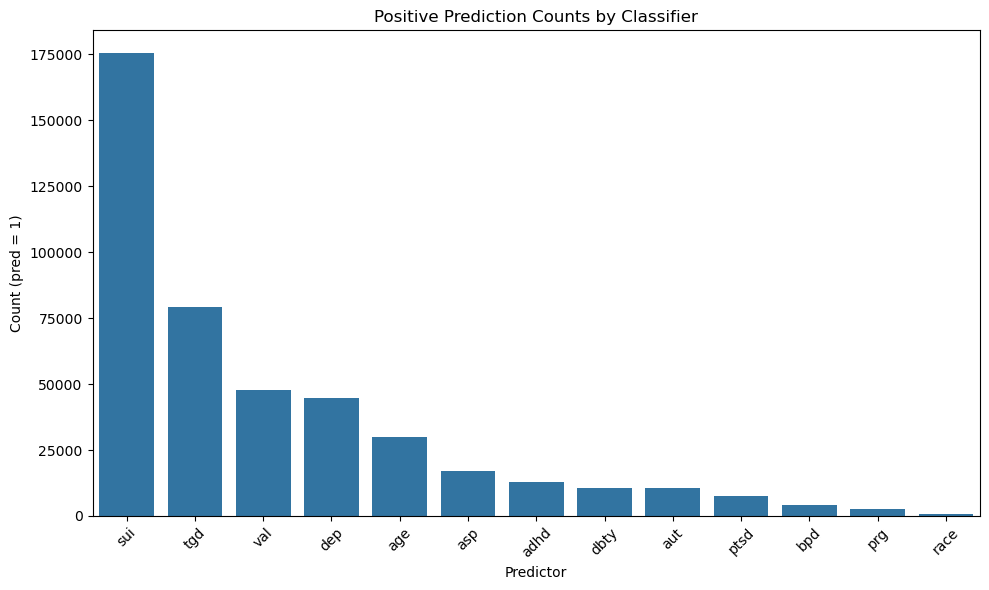

In [8]:
# Viz. counts

plot_pred_counts(d)

# Cell ID: 22d7536d

In [9]:
%%script false --no-raise-error
#############################################################################

# Simulate
N = 10_000
cols = [f'v{i:02d}' for i in range(10)]

d = pd.DataFrame(
    np.random.randint(0, 2, size=(N, len(cols))),
    columns=cols
)

# Inspect & verify
d
#############################################################################
# Cell ID: c4500d79

In [10]:
for col in d.columns:
    print(col)

asp
asp_prob
dep
dep_prob
val
val_prob
prg
prg_prob
tgd
tgd_prob
age
age_prob
race
race_prob
dbty
dbty_prob
gpe
sui
aut
adhd
bpd
ptsd


In [11]:
# Subset to manifest varlist

indicators = ['asp', 'dep', 'val', 'tgd', 'prg', 'age', 'race', 'dbty', 
                 'sui', 'aut', 'adhd', 'bpd', 'ptsd']

d_indicators = d[indicators]

d_indicators.head(5)

# Cell ID: 8d58e355

,asp,dep,val,tgd,prg,age,race,dbty,sui,aut,adhd,bpd,ptsd
0,1,0,0,0,0,1,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,0,0,0


In [15]:
# Latent class analysis / StepMix intro

### NOTE 8/5: working from the docs, this cell

# Categorical StepMix Model with 3 latent classes
model = StepMix(
    n_components=4, 
    measurement="binary", 
    verbose=1, 
    max_iter=5000, 
    n_init=1, 
    random_state=56,
    )
model.fit(d_indicators)

# Allow missing values
#model_nan = StepMix(n_components=3, measurement="binary_nan", random_state=56)
#model_nan.fit(d)

### NOTE: StepMix supports LatentGOLD-equivalent coviariates of class membership + distal outcomes

### NOTE: excellent model selection tutorial: https://colab.research.google.com/drive/1btXHCx90eCsnUlQv_yN-9AzKDhJP_JkG?usp=drive_link

# Cell ID: cbc9c827

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [11:36<00:00, 696.41s/it, max_LL=-1.64e+6, max_avg_LL=-1.41]


MODEL REPORT
    Measurement model parameters
          model_name      binary                        
          class_no             0       1       2       3
          param variable                                
          pis   adhd      0.0040  0.2390  0.0047  0.0122
                age       0.0134  0.0515  0.0172  0.0681
                asp       0.0062  0.0429  0.0202  0.0388
                aut       0.0020  0.2608  0.0093  0.0046
                bpd       0.0003  0.0564  0.0005  0.0092
                dbty      0.0000  0.0950  0.0037  0.0334
                dep       0.0000  0.1458  0.0120  0.1672
                prg       0.0024  0.0008  0.0001  0.0030
                ptsd      0.0011  0.1104  0.0008  0.0154
                race      0.0006  0.0035  0.0007  0.0003
                sui       0.1151  0.4508  0.0235  0.2834
                tgd       0.0000  0.0515  0.9580  0.0000
                val       0.0236  0.1233  0.2347  0.0265
    Class weights
        Class 1 : 0.70
 

,n_components,4
,n_steps,1
,measurement,'binary'
,structural,'gaussian_unit'
,assignment,'modal'
,correction,None
,abs_tol,1e-10
,rel_tol,0.0
,max_iter,5000
,n_init,1
,save_param_init,False


In [13]:
%%script false --no-raise-error
#############################################################################

### NOTE 8/14: shit's broken

# Grid search: n_components (1-8)

from tqdm import tqdm

param_grid = {
    'n_components': range(1, 9)
}

results = []

for n_comp in tqdm(param_grid['n_components'], desc='n_components'):
    model = StepMix(
        n_components=n_comp,
        measurement='binary',
        max_iter=5000,
        n_init=20,
        random_state=56,
        verbose=0
    )
    model.fit(d)
    
    results.append({
        'n_components': n_comp,
        'LL': model.score(d) * len(d),
        'AIC': model.aic(d),
        'BIC': model.bic(d),
        'CAIC': model.caic(d),
        'SABIC': model.sabic(d),
        'entropy': model.relative_entropy(d)
    })

#############################################################################
# Cell ID: a045b613

In [14]:
%%script false --no-raise-error
#############################################################################

# Inspect results
results_df = pd.DataFrame(results)
results_df.sort_values('BIC')

#############################################################################
# Cell ID: 26d75e12